In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DEGRADACIÓN
Compound  TyreLife      Mean  Median  Count
    HARD       2.0 96.392054 96.4540     37
    HARD       3.0 96.605000 96.7190     36
    HARD       4.0 96.696472 96.7010     36
    HARD       5.0 96.602459 96.6520     37
    HARD       6.0 96.720784 96.5480     37
    HARD       7.0 96.728784 96.6470     37
    HARD       8.0 96.696459 96.6440     37
    HARD       9.0 96.617676 96.7330     37
    HARD      10.0 96.637919 96.6910     37
    HARD      11.0 96.744389 96.6585     36
    HARD      12.0 96.749400 96.6830     35
    HARD      13.0 96.767242 96.6950     33
    HARD      14.0 96.948971 96.7200     34
    HARD      15.0 97.023606 96.9050     33
    HARD      16.0 96.935676 96.8290     34
    HARD      17.0 96.998676 96.8745     34
    HARD      18.0 97.121677 97.0660     31
    HARD      19.0 96.862571 96.9195     28
    HARD      20.0 96.728565 96.9100     23
    HARD      21.0 96.795353 96.8190     17
    HARD      22.0 96.580667 96.7410     15
    HARD      23.0 9

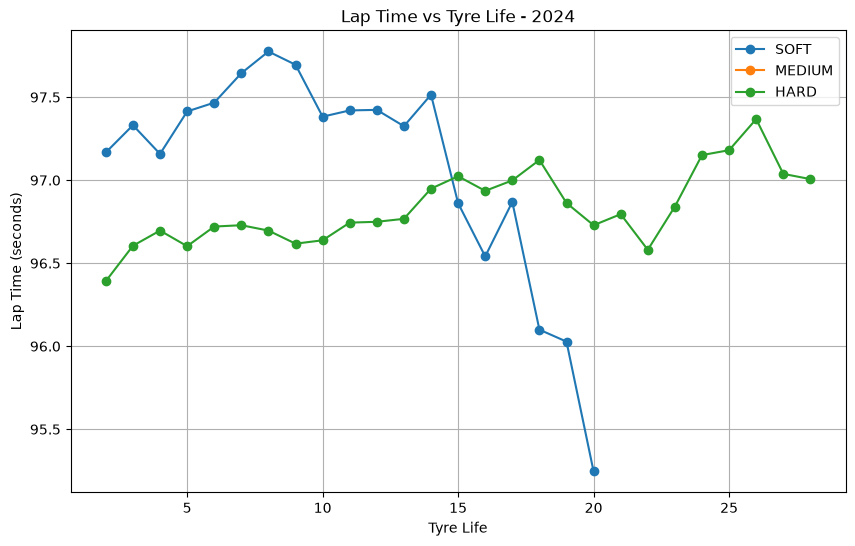

In [9]:
FILE = Path("data/processed/race_laps_2024.parquet")

df = pd.read_parquet(FILE)


# ------------------------------------------------------------
# Solo neumáticos de seco
# ------------------------------------------------------------

dry = df[
    (df["Race"] == "Sakhir") &
    (df["Compound"].isin(["SOFT", "MEDIUM", "HARD"]))
].copy()

# ------------------------------------------------------------
# Agrupar por edad del neumático
# ------------------------------------------------------------

degradation = (
    dry.groupby(
        ["Compound", "TyreLife"]
    )["LapTimeSeconds"]
    .agg(
        Mean="mean",
        Median="median",
        Count="count"
    )
    .reset_index()
)


# ------------------------------------------------------------
# Mostrar algunos datos
# ------------------------------------------------------------

print("=" * 70)
print("DEGRADACIÓN")
print("=" * 70)

print(
    degradation.head(30)
    .to_string(index=False)
)


# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))


for compound in ["SOFT", "MEDIUM", "HARD"]:

    data = degradation[
        degradation["Compound"] == compound
    ]

    # Solo edades con suficiente cantidad de vueltas
    data = data[
        data["Count"] >= 2
    ]

    plt.plot(
        data["TyreLife"],
        data["Mean"],
        marker="o",
        label=compound
    )


plt.xlabel("Tyre Life")
plt.ylabel("Lap Time (seconds)")
plt.title("Lap Time vs Tyre Life - 2024")
plt.legend()
plt.grid(True)

plt.show()

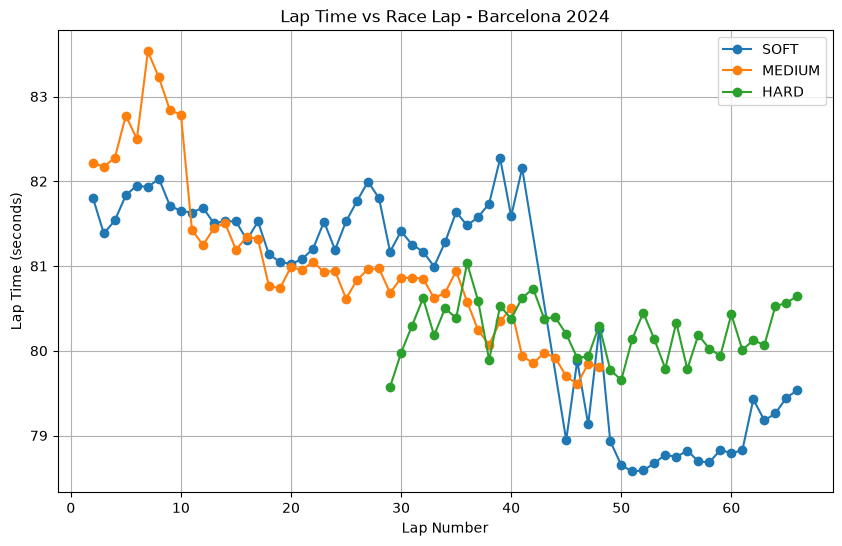

In [11]:
df = pd.read_parquet(FILE)

data = df[
    (df["Race"] == "Barcelona") &
    (df["Compound"].isin(["SOFT", "MEDIUM", "HARD"]))
].copy()

plt.figure(figsize=(10, 6))

for compound in ["SOFT", "MEDIUM", "HARD"]:
    subset = data[data["Compound"] == compound]

    grouped = (
        subset.groupby("LapNumber")["LapTimeSeconds"]
        .mean()
        .reset_index()
    )

    plt.plot(
        grouped["LapNumber"],
        grouped["LapTimeSeconds"],
        marker="o",
        label=compound
    )

plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.title("Lap Time vs Race Lap - Barcelona 2024")
plt.legend()
plt.grid(True)

plt.show()